In [7]:
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
import os, math
from dotenv import load_dotenv
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import RemoveMessage, HumanMessage, AIMessage, SystemMessage

from pydantic import BaseModel, Field
from IPython.display import display, Image

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY,
    model_kwargs={"system_instruction": "You are assistant"},
)




In [8]:
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))


for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


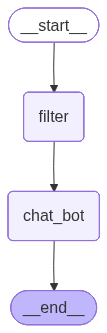

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a fantastic area to research! Beyond the large baleen whales and even the more commonly known toothed whales (like sperm whales), there's a whole world of other incredible ocean mammals.

Here are the main groups you should definitely learn about:

1.  **Dolphins & Porpoises:**
    *   **What they are:** These are actually part of the *toothed whale* suborder (Odontoceti), but they're often discussed separately due to their smaller size and distinct characteristics.
    *   **Key features:** Highly intelligent, social, use echolocation, known for their agility and playful behavior.
    *   **Examples:**
  

In [9]:
def filter(state: MessagesState) -> MessagesState:
    deleted_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": deleted_messages}


def chat_bot(state: MessagesState) -> MessagesState:
    return {"messages": llm.invoke(state["messages"])}


builder = StateGraph(MessagesState)
builder.add_node("filter", filter)
builder.add_node("chat_bot", chat_bot)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_bot")
builder.add_edge("chat_bot", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

response = graph.invoke({"messages": messages})
for m in response["messages"]:
    m.pretty_print()

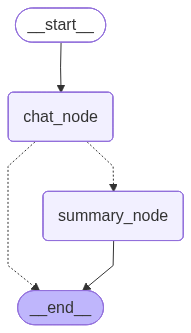

================================== Ai Message ==================================

Hi Amit! It's nice to meet you. I'm an AI assistant.

How can I help you today?
================================== Ai Message ==================================

That's fantastic, Amit! Cricket is a passion for so many people around the world.

What is it about cricket that you enjoy the most? Do you have a favorite team or player, or perhaps a specific format you follow closely, like Test matches, ODIs, or T20s?
================================== Ai Message ==================================

Ah, MS Dhoni! An excellent choice, Amit. He's an absolute legend of the game.

What a player and a captain he was! From his incredible finishing abilities and that iconic helicopter shot to his calm demeanor under pressure and his unparalleled leadership, he truly left an indelible mark on cricket. Winning all three ICC white-ball trophies as captain is a feat very few can boast of.

What is it about MS Dhoni that y

StateSnapshot(values={'messages': [HumanMessage(content='Tell me about Amit', additional_kwargs={}, response_metadata={}, id='ec6ac036-8c47-4b9b-8407-79686e1e87f3'), AIMessage(content="Okay, Amit, based on our conversation so far, here's what I know about you:\n\n1.  **Your name is Amit.**\n2.  **You like cricket.**\n3.  **Your favorite player is MS Dhoni.**\n\nThat's what I've learned about you in our chat! Is there anything else you'd like to share or discuss?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--ce17512f-b49b-4005-82f2-174bdfd16f85-0', usage_metadata={'input_tokens': 220, 'output_tokens': 588, 'total_tokens': 808, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 509}})], 'summary': "Here's a summary of our conversation so far:\n\nThe conversation began with you, Amit, introducing yourself. I then

In [10]:
from typing import Literal


class State(MessagesState):
    summary: str


def chat_node(state: State) -> State:
    summary = state.get("summary", "")
    if summary:
        system_message = SystemMessage(f"Here is the Summary for existing converstation, please respond based on that. Summary: {summary}")
        messages = [system_message] + state["messages"]
    else: 
        messages = state["messages"]   

    return {"messages": [llm.invoke(messages)], "summary": state.get("summary", "")}


def summary_node(state: State) -> State:
    summary = state.get("summary", "")
    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)

    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}


def decide_node(state: State) -> Literal["summary_node", END]:
    if len(state["messages"]) > 6:
        return "summary_node"
    return END


memory = MemorySaver()
config = {"configurable": {"thread_id": "chat_1"}}
builder = StateGraph(State)

builder.add_node("chat_node", chat_node)
builder.add_node("summary_node", summary_node)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges("chat_node", decide_node)
builder.add_edge("summary_node", END)

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


response = graph.invoke({"messages": [HumanMessage("Hello I'm Amit")]}, config=config)

for m in response["messages"][-1:]:
    m.pretty_print()


response = graph.invoke({"messages": [HumanMessage("I like cricket")]}, config=config)
for m in response["messages"][-1:]:
    m.pretty_print()

response = graph.invoke({"messages": [HumanMessage("I like MS Dhoni")]}, config=config)
for m in response["messages"][-1:]:
    m.pretty_print()

response = graph.invoke({"messages": [HumanMessage("Tell me about Amit")]}, config=config)
for m in response["messages"][-1:]:
    m.pretty_print()


state = graph.get_state(config)
state
